# COMPARISON VCAE VS HQVAE — Ruido mixto fijo: Gaussian + Salt & Pepper

Este cuaderno deriva de `vcae_VS_hqvae_adamw_12.ipynb`, manteniendo exactamente la misma pipeline (mismo preprocesado, mismos modelos ConvVAE / ConvHQVAE, mismo QNN, mismo entrenamiento y mismas metricas), pero **cada imagen recibe siempre el mismo tipo de ruido mixto: Gaussian + Salt & Pepper** (en el notebook original el tipo de ruido mixto se sorteaba aleatoriamente por imagen entre 3 combinaciones).

Split de datos (igual que el original, por cada tipo de ruido / notebook):
- Train: 300 imagenes
- Val: 100 imagenes
- Test: 100 imagenes


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import cat
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F

### 2. **REPRODUCIBILIDAD (SEED)**

In [2]:
import random
import os
import numpy as np
import torch

SEED = 42

# Python
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch CUDA
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Reproducibilidad CUDA/cuDNN
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Opcional: operaciones deterministas estrictas
# torch.use_deterministic_algorithms(True)

print(f"Seed fijada: {SEED}")

Seed fijada: 42


In [3]:
transform = transforms.Compose([transforms.ToTensor()])
# transform = transforms.Compose([
#     transforms.Resize((32, 32)),
#     transforms.ToTensor()
# ])

X_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
X_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

In [4]:
n_samples_train = 400
n_samples_test = 100

X_train.data = X_train.data[:n_samples_train]
X_train.targets = X_train.targets[:n_samples_train]

X_test.data = X_test.data[:n_samples_test]
X_test.targets = X_test.targets[:n_samples_test]

In [5]:
train_size = 300
val_size = 100

split_generator = torch.Generator()
split_generator.manual_seed(SEED)

train_subset, val_subset = random_split(
    X_train,
    [train_size, val_size],
    generator=split_generator
)

In [6]:
def gaussian_noise(img, sigma=0.25, generator=None):
    noise = torch.randn(
        img.shape,
        generator=generator,
        dtype=img.dtype
    ) * sigma

    return torch.clamp(img + noise, 0, 1)


def salt_pepper(img, prob=0.15, generator=None):
    noisy = img.clone()

    mask = torch.rand(
        img.shape,
        generator=generator,
        dtype=img.dtype
    )

    noisy[mask < prob / 2] = 0
    noisy[mask > 1 - prob / 2] = 1

    return noisy


def speckle(img, sigma=0.35, generator=None):
    noise = torch.randn(
        img.shape,
        generator=generator,
        dtype=img.dtype
    ) * sigma

    return torch.clamp(img + img * noise, 0, 1)


def apply_mixed_noise(img, generator):
    # Ruido mixto FIJO para este notebook: Gaussian + Salt & Pepper
    # (en el notebook original, este mismo 'label' se sorteaba al azar entre 0/1/2;
    # aqui se fuerza siempre a la misma combinacion para aislar este tipo de ruido)
    img = gaussian_noise(img, generator=generator)
    img = salt_pepper(img, generator=generator)
    label = 1

    return img, label


In [7]:
class NoisyMNISTDataset(Dataset):
    def __init__(self, mnist_dataset, seed):
        self.mnist = mnist_dataset

        self.generator = torch.Generator()
        self.generator.manual_seed(seed)

        self.noisy_images = []
        self.labels = []

        for img, _ in self.mnist:
            noisy_img, label = apply_mixed_noise(
                img,
                generator=self.generator
            )

            self.noisy_images.append(noisy_img)
            self.labels.append(label)

        if len(self.noisy_images) != len(self.labels):
            raise Exception("Incompatible arrays")

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        return self.noisy_images[idx], self.labels[idx]
    

train_dataset = NoisyMNISTDataset(train_subset, seed=SEED)
val_dataset   = NoisyMNISTDataset(val_subset, seed=SEED + 1)
test_dataset  = NoisyMNISTDataset(X_test, seed=SEED + 2)

In [8]:
train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    generator=train_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

images, labels = next(iter(train_loader))

print(images.shape)  # [32, 1, 28, 28]
print(labels.shape)


torch.Size([32, 1, 28, 28])
torch.Size([32])


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 3. Denoising con VAE hibrido (ConvHQVAE)

Se reutiliza el dataset ruidoso, pero ahora el objetivo es reconstruir la imagen limpia. El encoder es convolucional y el espacio latente se procesa mediante un QNN antes del decoder.

**TO DO**: justificar la dimension latente y el numero de qubits.

In [10]:
class DenoisingMNISTDataset(Dataset):
    def __init__(self, mnist_dataset, seed):
        self.mnist = mnist_dataset

        self.generator = torch.Generator()
        self.generator.manual_seed(seed)

        self.noisy_images = []
        self.clean_images = []

        for img, _ in self.mnist:
            clean_img = img

            noisy_img, _ = apply_mixed_noise(
                img,
                generator=self.generator
            )

            self.clean_images.append(clean_img)
            self.noisy_images.append(noisy_img)

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        return self.noisy_images[idx], self.clean_images[idx]

In [11]:
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import pauli_feature_map
from qiskit.primitives import StatevectorEstimator as Estimator
estimator = Estimator()
observables = [ # CORRELACIÓN de anillo
    SparsePauliOp.from_list([("ZZIIII", 1.0)]),  # q0-q1
    SparsePauliOp.from_list([("IZZIII", 1.0)]),  # q1-q2
    SparsePauliOp.from_list([("IIZZII", 1.0)]),  # q2-q3
    SparsePauliOp.from_list([("IIIZZI", 1.0)]),  # q3-q4
    SparsePauliOp.from_list([("IIIIZZ", 1.0)]),  # q4-q5
    SparsePauliOp.from_list([("ZIIIIZ", 1.0)]),  # q5-q0
]
def create_qnn_vae():
    n_qubits = 6
    # feature_map = pauli_feature_map(n_qubits=n_qubits, paulis=['X','Y','ZZ'], reps=1, entanglement="full")
    feature_map = zz_feature_map(n_qubits, reps=1, entanglement="full")
    ansatz = real_amplitudes(n_qubits, entanglement="linear", reps=1)
    qc = QuantumCircuit(n_qubits)
    qc.compose(feature_map, inplace=True)
    qc.compose(ansatz, inplace=True)

    qnn = EstimatorQNN(
        circuit=qc,
        input_params=feature_map.parameters,
        weight_params=ansatz.parameters,
        input_gradients=True,
        estimator=estimator,
        observables=observables
    )
    return qnn

qnn_vae = create_qnn_vae()

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


### 3.1. Estructura del encoder y decoder

El ConvHQVAE combina un encoder convolucional clasico con un bloque cuantico que transforma el vector latente. La salida cuantica se concatena con el propio latente para preservar informacion antes de decodificar.

- Encoder: `Conv2d(1 -> 32 -> 64)` + `Flatten`.
- Espacio latente: `fc_mu`, `fc_logvar`.
- QNN: `EstimatorQNN` con 6 qubits y observables en Z.
- Decoder: `ConvTranspose2d` hasta reconstruir $1 \times 28 \times 28$.

**TO DO**: agregar un esquema visual del pipeline ConvHQVAE.

In [12]:
class ConvVAE(nn.Module):

    def __init__(self, latent_dim=6):

        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),

            nn.Flatten()
        )

        # Latent space
        self.fc_mu = nn.Linear(3136, latent_dim)
        self.fc_logvar = nn.Linear(3136, latent_dim)

        # Classical latent transformation
        self.latent_transform = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, len(observables))
        )

        # Decoder
        self.fc_decode = nn.Linear(
            latent_dim + len(observables),
            3136
        )

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),

            nn.ConvTranspose2d(
                64, 32,
                4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                32, 1,
                4,
                stride=2,
                padding=1
            ),
            nn.Sigmoid()
        )


    def encode(self, x):

        h = self.encoder(x)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar


    def reparametrize(self, mu, logvar):

        sigma = torch.exp(0.5 * logvar)

        return mu + sigma * torch.randn_like(sigma)


    def decode(self, z):

        z_classical = self.latent_transform(z)

        z_combined = torch.cat(
            [z, z_classical],
            dim=1
        )

        h = self.fc_decode(z_combined)

        return self.decoder(h)


    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparametrize(mu, logvar)

        recon = self.decode(z)

        return recon, mu, logvar

    def reconstruct(self, x):
        mu, logvar = self.encode(x)
        return self.decode(mu)

In [13]:
class ConvHQVAE(nn.Module):
    def __init__(self, latent_dim=12, qnn=None):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(3136, latent_dim)
        self.fc_logvar = nn.Linear(3136, latent_dim)

        self.qnn = TorchConnector(qnn) if qnn is not None else nn.Identity()

        # Proyección clásica latent_dim -> nº de qubits de entrada del QNN.
        # El circuito (ZZFeatureMap, 6 qubits) solo acepta un vector de
        # entrada de longitud fija (qnn.num_inputs); si latent_dim coincide
        # con esa longitud (p. ej. 6, como en la config. original) la capa
        # es una Identity y no cambia nada. Con latent_dim=12 (adamw_12)
        # es necesaria para no romper la forma del tensor en decode().
        n_qnn_inputs = qnn.num_inputs if qnn is not None else latent_dim
        self.to_qnn = (
            nn.Linear(latent_dim, n_qnn_inputs)
            if latent_dim != n_qnn_inputs else nn.Identity()
        )

        # Ahora fc_decode recibe latent + salida QNN
        self.fc_decode = nn.Linear(latent_dim + len(observables), 3136)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64,7,7)),
            nn.ConvTranspose2d(64,32,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,stride=2,padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparametrize(self, mu, logvar):
        sigma = torch.exp(0.5*logvar)
        return mu + sigma*torch.randn_like(sigma)

    def decode(self, z):
        z_qnn = self.qnn(self.to_qnn(z))
        # Concatenamos para que no se pierda información
        z_combined = torch.cat([z, z_qnn], dim=1)
        return self.decoder(self.fc_decode(z_combined))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        return self.decode(z), mu, logvar

    def reconstruct(self, x):
        mu, logvar = self.encode(x)
        return self.decode(mu)

In [14]:
train_dataset_dn = DenoisingMNISTDataset(train_subset, seed=SEED)
val_dataset_dn   = DenoisingMNISTDataset(val_subset, seed=SEED + 1)
test_dataset_dn  = DenoisingMNISTDataset(X_test, seed=SEED + 2)

train_generator_dn = torch.Generator()
train_generator_dn.manual_seed(SEED)

train_loader_dn = DataLoader(
    train_dataset_dn,
    batch_size=16,
    shuffle=True,
    generator=train_generator_dn
)

val_loader_dn = DataLoader(
    val_dataset_dn,
    batch_size=16,
    shuffle=False
)

test_loader_dn = DataLoader(
    test_dataset_dn,
    batch_size=16,
    shuffle=False
)

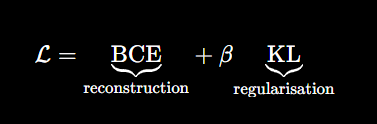

- BCE mide qué bien reconstruye la imagen.
- KL mide cuánto se aleja el espacio latente aprendido de una distribución normal estándar.
- Loss total es la suma de ambas.

In [15]:
def vae_loss(recon_x, x, mu, logvar, beta=0.5):

    bce = F.binary_cross_entropy(
        recon_x,
        x,
        reduction='sum'
    ) / x.size(0)

    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    ) / x.size(0)

    total = bce + beta * kl

    return total, bce, kl

In [16]:
model_cvae = ConvVAE(latent_dim=12).to(device)  # adamw_12

optimizer_cvae = optim.Adam(
    model_cvae.parameters(),
    lr=1e-3
)

EPOCHS = 15

# Pérdida total
cvae_train_loss = []
cvae_val_loss = []

# BCE
cvae_train_bce = []
cvae_val_bce = []

# KL
cvae_train_kl = []
cvae_val_kl = []

# Calcular tiempo de entrenamiento
import time
start_time = time.time()

for epoch in range(1, EPOCHS + 1):

    # =========================
    # TRAIN
    # =========================

    model_cvae.train()

    train_loss = 0
    train_bce = 0
    train_kl = 0
    n_train = 0

    for noisy, clean in train_loader_dn:

        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer_cvae.zero_grad()

        recon, mu, logvar = model_cvae(noisy)

        loss, bce, kl = vae_loss(
            recon,
            clean,
            mu,
            logvar
        )

        loss.backward()
        optimizer_cvae.step()

        batch_size = noisy.size(0)

        train_loss += loss.item() * batch_size
        train_bce += bce.item() * batch_size
        train_kl += kl.item() * batch_size

        n_train += batch_size

    train_loss /= n_train
    train_bce /= n_train
    train_kl /= n_train


    # =========================
    # VALIDATION
    # =========================

    model_cvae.eval()

    val_loss = 0
    val_bce = 0
    val_kl = 0
    n_val = 0

    with torch.no_grad():

        for noisy, clean in val_loader_dn:

            noisy = noisy.to(device)
            clean = clean.to(device)

            recon, mu, logvar = model_cvae(noisy)

            loss, bce, kl = vae_loss(
                recon,
                clean,
                mu,
                logvar
            )

            batch_size = noisy.size(0)

            val_loss += loss.item() * batch_size
            val_bce += bce.item() * batch_size
            val_kl += kl.item() * batch_size

            n_val += batch_size

    val_loss /= n_val
    val_bce /= n_val
    val_kl /= n_val


    # =========================
    # GUARDAR MÉTRICAS
    # =========================

    cvae_train_loss.append(train_loss)
    cvae_val_loss.append(val_loss)

    cvae_train_bce.append(train_bce)
    cvae_val_bce.append(val_bce)

    cvae_train_kl.append(train_kl)
    cvae_val_kl.append(val_kl)


    # =========================
    # MOSTRAR MÉTRICAS
    # =========================

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train BCE: {train_bce:.4f} | "
        f"Val BCE: {val_bce:.4f} | "
        f"Train KL: {train_kl:.4f} | "
        f"Val KL: {val_kl:.4f}"
    )



# tiempo de entrenamiento
end_time = time.time()
training_time = end_time - start_time

print(f"Tiempo de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo en minutos y segundos: {int(training_time // 60)} minutos y {int(training_time % 60)} segundos")



Epoch 01/15 | Train Loss: 403.8967 | Val Loss: 260.7672 | Train BCE: 380.5429 | Val BCE: 243.2147 | Train KL: 46.7077 | Val KL: 35.1049
Epoch 02/15 | Train Loss: 234.1735 | Val Loss: 220.3381 | Train BCE: 220.5885 | Val BCE: 214.4940 | Train KL: 27.1700 | Val KL: 11.6881
Epoch 03/15 | Train Loss: 213.8404 | Val Loss: 211.6617 | Train BCE: 206.6352 | Val BCE: 206.5482 | Train KL: 14.4104 | Val KL: 10.2270
Epoch 04/15 | Train Loss: 207.7972 | Val Loss: 207.8895 | Train BCE: 202.5127 | Val BCE: 203.3132 | Train KL: 10.5690 | Val KL: 9.1526
Epoch 05/15 | Train Loss: 203.4720 | Val Loss: 203.2365 | Train BCE: 198.3645 | Val BCE: 197.6861 | Train KL: 10.2150 | Val KL: 11.1008
Epoch 06/15 | Train Loss: 199.8194 | Val Loss: 198.1876 | Train BCE: 194.0544 | Val BCE: 191.8384 | Train KL: 11.5300 | Val KL: 12.6984
Epoch 07/15 | Train Loss: 193.9719 | Val Loss: 192.6890 | Train BCE: 187.5966 | Val BCE: 186.9550 | Train KL: 12.7506 | Val KL: 11.4681
Epoch 08/15 | Train Loss: 183.0946 | Val Loss: 17

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_hqvae = ConvHQVAE(latent_dim=12, qnn=qnn_vae).to(device)  # adamw_12
optimizer = optim.AdamW(model_hqvae.parameters(), lr=1e-3)  # adamw_12
# NOTA: el ConvVAE clásico (optimizer_cvae, celda anterior) se deja en Adam.
# El informe original no distingue si 'optimizer' se aplicó también al
# baseline clásico; con weight_decay=0 (por defecto) AdamW y Adam son
# matemáticamente equivalentes, así que esta asunción no afecta al
# resultado del ConvVAE. Si el criterio real era aplicarlo a ambos,
# basta con cambiar también optimizer_cvae a optim.AdamW.

EPOCHS = 15

# Guardar métricas
train_loss_list = []
val_loss_list = []

train_bce_list = []
val_bce_list = []

train_kl_list = []
val_kl_list = []

# Calcular tiempo de entrenamiento
import time
start_time = time.time()

for epoch in range(1, EPOCHS + 1):

    # =========================================================
    # TRAIN
    # =========================================================
    model_hqvae.train()

    train_total = 0
    train_bce = 0
    train_kl = 0
    n_train = 0

    for noisy, clean in train_loader_dn:

        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model_hqvae(noisy)

        loss, bce, kl = vae_loss(
            recon,
            clean,
            mu,
            logvar
        )

        loss.backward()
        optimizer.step()

        batch_size = noisy.size(0)

        train_total += loss.item() * batch_size
        train_bce += bce.item() * batch_size
        train_kl += kl.item() * batch_size

        n_train += batch_size

    train_total /= n_train
    train_bce /= n_train
    train_kl /= n_train


    # =========================================================
    # VALIDATION
    # =========================================================
    model_hqvae.eval()

    val_total = 0
    val_bce = 0
    val_kl = 0
    n_val = 0

    with torch.no_grad():

        for noisy, clean in val_loader_dn:

            noisy = noisy.to(device)
            clean = clean.to(device)

            recon, mu, logvar = model_hqvae(noisy)

            loss, bce, kl = vae_loss(
                recon,
                clean,
                mu,
                logvar
            )

            batch_size = noisy.size(0)

            val_total += loss.item() * batch_size
            val_bce += bce.item() * batch_size
            val_kl += kl.item() * batch_size

            n_val += batch_size

    val_total /= n_val
    val_bce /= n_val
    val_kl /= n_val


    # Guardar
    train_loss_list.append(train_total)
    val_loss_list.append(val_total) 

    train_bce_list.append(train_bce)
    val_bce_list.append(val_bce)

    train_kl_list.append(train_kl)
    val_kl_list.append(val_kl)


    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_total:.4f} | "
        f"Val Loss: {val_total:.4f} | "
        f"Train BCE: {train_bce:.4f} | "
        f"Val BCE: {val_bce:.4f} | "
        f"Train KL: {train_kl:.4f} | "
        f"Val KL: {val_kl:.4f}"
    )

# tiempo de entrenamiento
end_time = time.time()
training_time = end_time - start_time

print(f"Tiempo de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo en minutos y segundos: {int(training_time // 60)} minutos y {int(training_time % 60)} segundos")

Epoch 01/15 | Train Loss: 388.3448 | Val Loss: 266.4289 | Train BCE: 366.9356 | Val BCE: 239.9550 | Train KL: 42.8183 | Val KL: 52.9478
Epoch 02/15 | Train Loss: 239.1068 | Val Loss: 222.6520 | Train BCE: 222.2174 | Val BCE: 214.4981 | Train KL: 33.7789 | Val KL: 16.3079
Epoch 03/15 | Train Loss: 216.1541 | Val Loss: 214.6953 | Train BCE: 209.1332 | Val BCE: 208.2555 | Train KL: 14.0417 | Val KL: 12.8795
Epoch 04/15 | Train Loss: 209.8342 | Val Loss: 210.0970 | Train BCE: 203.5466 | Val BCE: 205.4786 | Train KL: 12.5751 | Val KL: 9.2368
Epoch 05/15 | Train Loss: 205.7483 | Val Loss: 205.8922 | Train BCE: 199.9295 | Val BCE: 200.7373 | Train KL: 11.6376 | Val KL: 10.3097
Epoch 06/15 | Train Loss: 202.3240 | Val Loss: 201.5228 | Train BCE: 196.3314 | Val BCE: 194.2896 | Train KL: 11.9853 | Val KL: 14.4665
Epoch 07/15 | Train Loss: 195.1034 | Val Loss: 192.7881 | Train BCE: 188.3164 | Val BCE: 185.7588 | Train KL: 13.5740 | Val KL: 14.0584
Epoch 08/15 | Train Loss: 186.8230 | Val Loss: 18

## 4. Resultados y Conclusiones

In [18]:
def show_reconstructions(
    model_cvae,
    model_hqvae,
    dataloader,
    device,
    n_images=8
):

    model_cvae.eval()
    model_hqvae.eval()

    # Obtener un batch
    images, labels = next(iter(dataloader))

    images = images[:n_images].to(device)
    labels = labels[:n_images]

    # Reconstrucción determinista usando mu
    with torch.no_grad():

        recon_cvae = model_cvae.reconstruct(images)
        recon_hqvae = model_hqvae.reconstruct(images)

    # Pasar a CPU para visualizar
    images = images.cpu()
    recon_cvae = recon_cvae.cpu()
    recon_hqvae = recon_hqvae.cpu()

    noise_names = {
        0: "Gaussian + Speckle",
        1: "Gaussian + Salt-Pepper",
        2: "Salt-Pepper + Speckle"
    }

    # Crear figura
    fig, axes = plt.subplots(
        3,
        n_images,
        figsize=(2 * n_images, 6)
    )

    if n_images == 1:
        axes = axes.reshape(3, 1)

    for i in range(n_images):

        # -------------------------
        # Imagen ruidosa
        # -------------------------
        axes[0, i].imshow(
            images[i].squeeze(),
            cmap="gray"
        )

        axes[0, i].set_title(
            noise_names[int(labels[i])],
            fontsize=9
        )

        axes[0, i].axis("off")

        # -------------------------
        # CVAE
        # -------------------------
        axes[1, i].imshow(
            recon_cvae[i].squeeze(),
            cmap="gray"
        )

        axes[1, i].axis("off")

        # -------------------------
        # HQVAE
        # -------------------------
        axes[2, i].imshow(
            recon_hqvae[i].squeeze(),
            cmap="gray"
        )

        axes[2, i].axis("off")

    # Etiquetas de las filas
    axes[0, 0].set_ylabel(
        "Noisy input",
        fontsize=11
    )

    axes[1, 0].set_ylabel(
        "CVAE",
        fontsize=11
    )

    axes[2, 0].set_ylabel(
        "HQVAE",
        fontsize=11
    )

    plt.suptitle(
        "Visual comparison of CVAE and HQVAE reconstructions\n(Noise: Gaussian + Salt & Pepper)",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

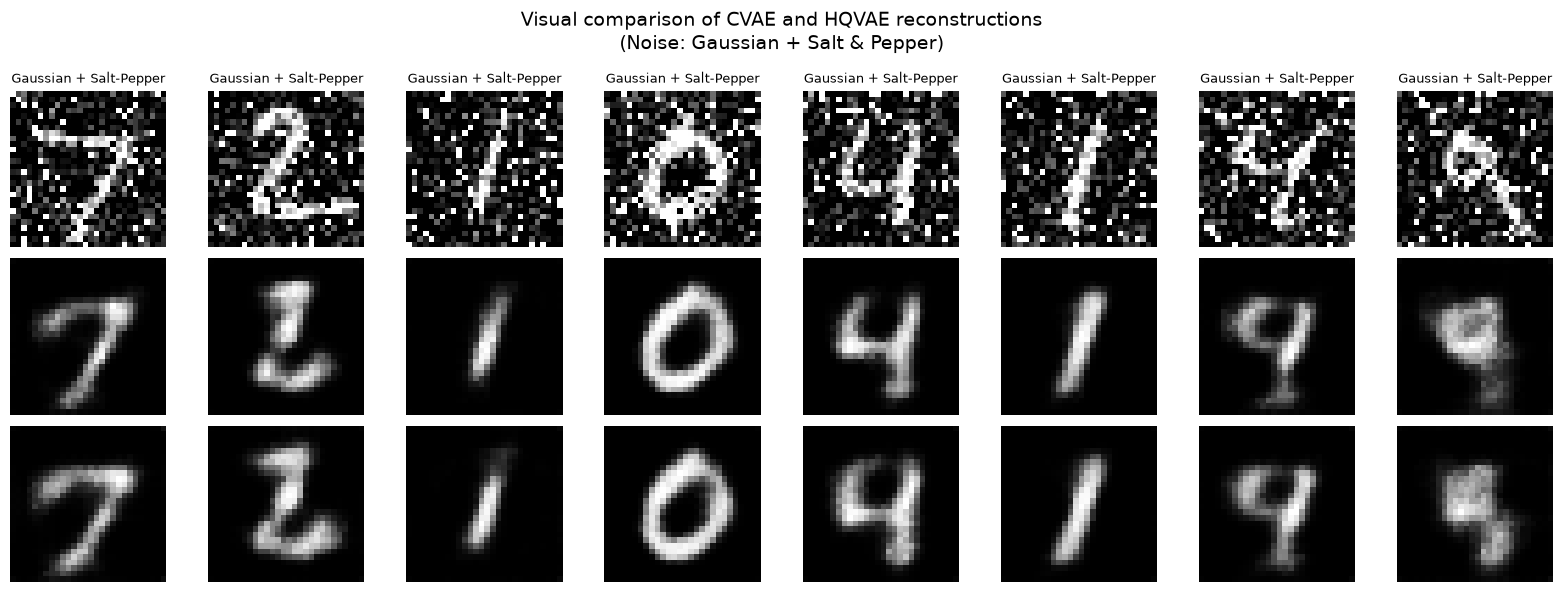

In [19]:
show_reconstructions( 
    model_cvae=model_cvae,
    model_hqvae=model_hqvae,
    dataloader=test_loader,
    device=device,
    n_images=8
)

In [20]:
from sklearn.metrics import mean_squared_error
import numpy as np
import torch


def evaluate_vae(model, dataset, device):

    model.eval()

    mse_list = []
    psnr_list = []

    with torch.no_grad():

        for noisy, clean in DataLoader(
            dataset,
            batch_size=32,
            shuffle=False
        ):

            noisy = noisy.to(device)
            clean = clean.to(device)
            
            # en este caso, no necesitamos mu y logvar, solo la reconstrucción
            # recon, _, _ = model(noisy)

            recon = model.reconstruct(noisy)

            mse = F.mse_loss(
                recon,
                clean,
                reduction='none'
            )

            mse = mse.view(mse.size(0), -1).mean(dim=1)

            mse_list.extend(
                mse.cpu().numpy()
            )

            psnr = 10 * np.log10(
                1.0 / (mse.cpu().numpy() + 1e-10)
            )

            psnr_list.extend(psnr)

    return {
        "MSE": np.mean(mse_list),
        "PSNR": np.mean(psnr_list)
    }

In [21]:
hqvae_results = evaluate_vae(
    model_hqvae,
    test_dataset_dn,
    device
)

cvae_results = evaluate_vae(
    model_cvae,
    test_dataset_dn,
    device
)

print("Classical VAE:")
print(cvae_results)

print("\nHybrid HQVAE:")
print(hqvae_results)

Classical VAE:
{'MSE': np.float32(0.036899354), 'PSNR': np.float32(14.733019)}

Hybrid HQVAE:
{'MSE': np.float32(0.035711266), 'PSNR': np.float32(14.862864)}


In [22]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Classical VAE",
        "Hybrid HQVAE"
    ],

    "Noise": ["Gaussian + Salt & Pepper", "Gaussian + Salt & Pepper"],

    "MSE": [
        cvae_results["MSE"],
        hqvae_results["MSE"]
    ],

    "PSNR": [
        cvae_results["PSNR"],
        hqvae_results["PSNR"]
    ]
})

comparison


,Model,Noise,MSE,PSNR
0,Classical VAE,Gaussian + Salt & Pepper,0.036899,14.733019
1,Hybrid HQVAE,Gaussian + Salt & Pepper,0.035711,14.862864


In [23]:
import sys
import subprocess
from pathlib import Path

notebook = Path("vcae_VS_hqvae_gaussian_saltpepper.ipynb").resolve()
output_dir = notebook.parent

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "nbconvert",
        "--to", "html",
        str(notebook),
        "--output-dir", str(output_dir),
    ],
    capture_output=True,
    text=True
)

print("RETURN CODE:", result.returncode)
print("\n--- STDOUT ---")
print(result.stdout)
print("\n--- STDERR ---")
print(result.stderr)

if result.returncode == 0:
    html_file = output_dir / "vcae_VS_hqvae_gaussian_saltpepper.html"
    print(f"\n HTML generado correctamente:")
    print(html_file)

RETURN CODE: 0

--- STDOUT ---


--- STDERR ---
[NbConvertApp] Converting notebook C:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\test-hqvae\vcae_VS_hqvae_gaussian_saltpepper.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 513050 bytes to C:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\test-hqvae\vcae_VS_hqvae_gaussian_saltpepper.html


 HTML generado correctamente:
C:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\test-hqvae\vcae_VS_hqvae_gaussian_saltpepper.html
